**1. Word Embeddings and Vector Representations**




Exercise 1: One-hot Encoding and TF-IDF


In [ ]:
!pip install matplotlib pandas scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [ ]:
corpus = [
    "Yoga in the mountains of Almaty brings peace to the soul",
    "Life in Almaty is a blend of nature, culture, and calm moments",
    "Morning yoga helps people start their day with balance and energy",
    "Almaty's fresh air and scenic views make meditation even more powerful",
    "Practicing yoga regularly brings clarity and joy to daily life"
]A


In [ ]:
# Initialize CountVectorizer with binary=True for one-hot encoding
onehot_vectorizer = CountVectorizer(binary=True)
onehot_matrix = onehot_vectorizer.fit_transform(corpus)

# Convert to DataFrame for easy viewing
onehot_df = pd.DataFrame(onehot_matrix.toarray(), columns=onehot_vectorizer.get_feature_names_out())
print(" One-hot Encoded Matrix:\n")
print(onehot_df)


 One-hot Encoded Matrix:

   air  almaty  and  balance  blend  brings  calm  clarity  culture  daily  \
0    0       1    0        0      0       1     0        0        0      0   
1    0       1    1        0      1       0     1        0        1      0   
2    0       0    1        1      0       0     0        0        0      0   
3    1       1    1        0      0       0     0        0        0      0   
4    0       0    1        0      0       1     0        1        0      1   

   ...  regularly  scenic  soul  start  the  their  to  views  with  yoga  
0  ...          0       0     1      0    1      0   1      0     0     1  
1  ...          0       0     0      0    0      0   0      0     0     0  
2  ...          0       0     0      1    0      1   0      0     1     1  
3  ...          0       1     0      0    0      0   0      1     0     0  
4  ...          1       0     0      0    0      0   1      0     0     1  

[5 rows x 41 columns]


In [ ]:
# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("\n🔍 TF-IDF Matrix:\n")
print(tfidf_df.round(3))



🔍 TF-IDF Matrix:

    air  almaty    and  balance  blend  brings   calm  clarity  culture  \
0  0.00   0.207  0.000     0.00  0.000   0.249  0.000     0.00    0.000   
1  0.00   0.227  0.191     0.00  0.339   0.000  0.339     0.00    0.339   
2  0.00   0.000  0.180     0.32  0.000   0.000  0.000     0.00    0.000   
3  0.32   0.214  0.180     0.00  0.000   0.000  0.000     0.00    0.000   
4  0.00   0.000  0.203     0.00  0.000   0.290  0.000     0.36    0.000   

   daily  ...  regularly  scenic   soul  start    the  their     to  views  \
0   0.00  ...       0.00    0.00  0.309   0.00  0.617   0.00  0.249   0.00   
1   0.00  ...       0.00    0.00  0.000   0.00  0.000   0.00  0.000   0.00   
2   0.00  ...       0.00    0.00  0.000   0.32  0.000   0.32  0.000   0.00   
3   0.00  ...       0.00    0.32  0.000   0.00  0.000   0.00  0.000   0.32   
4   0.36  ...       0.36    0.00  0.000   0.00  0.000   0.00  0.290   0.00   

   with   yoga  
0  0.00  0.207  
1  0.00  0.000  
2  0.32  0

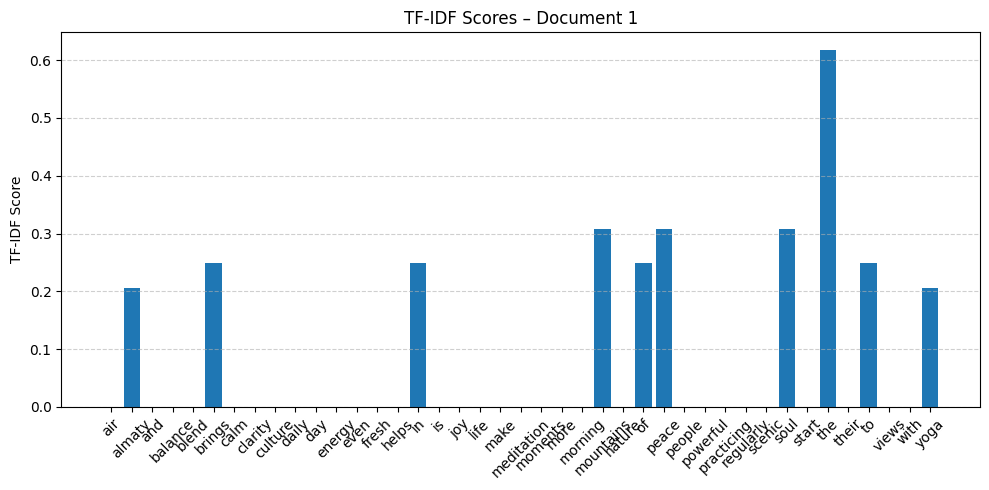

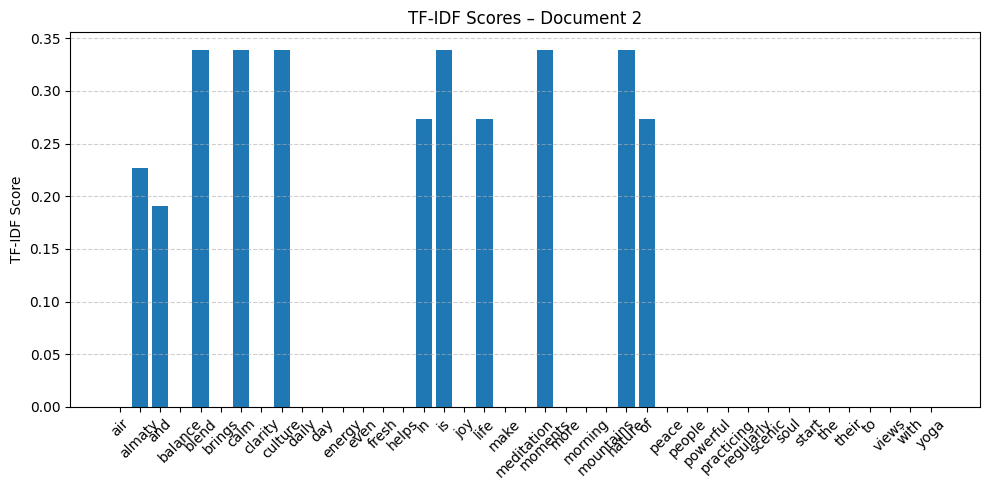

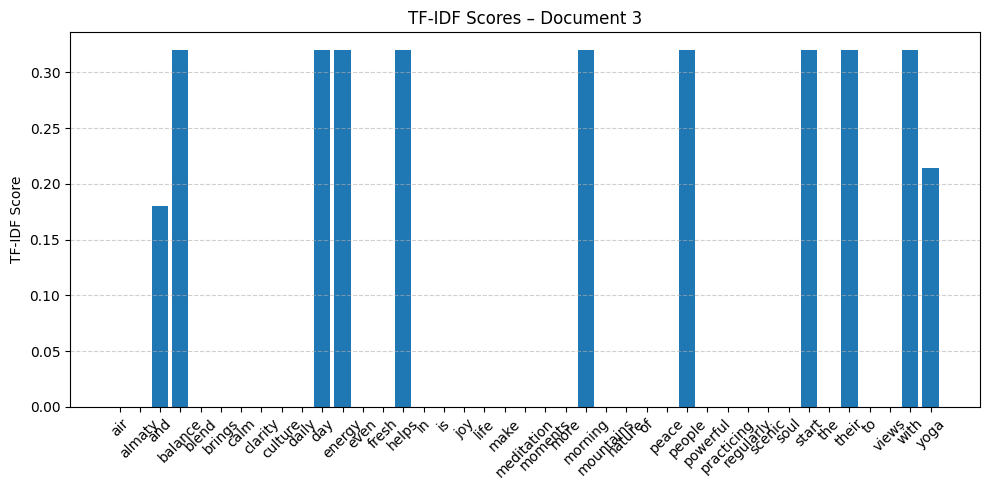

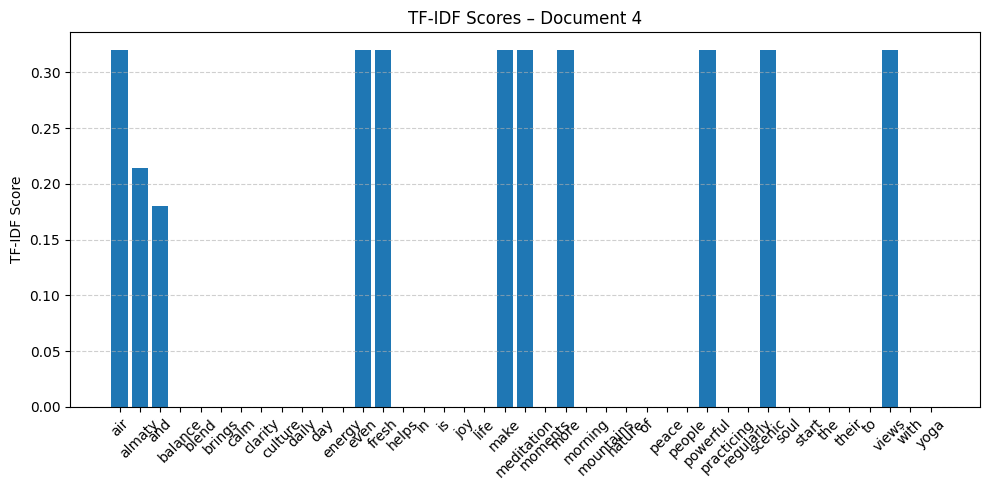

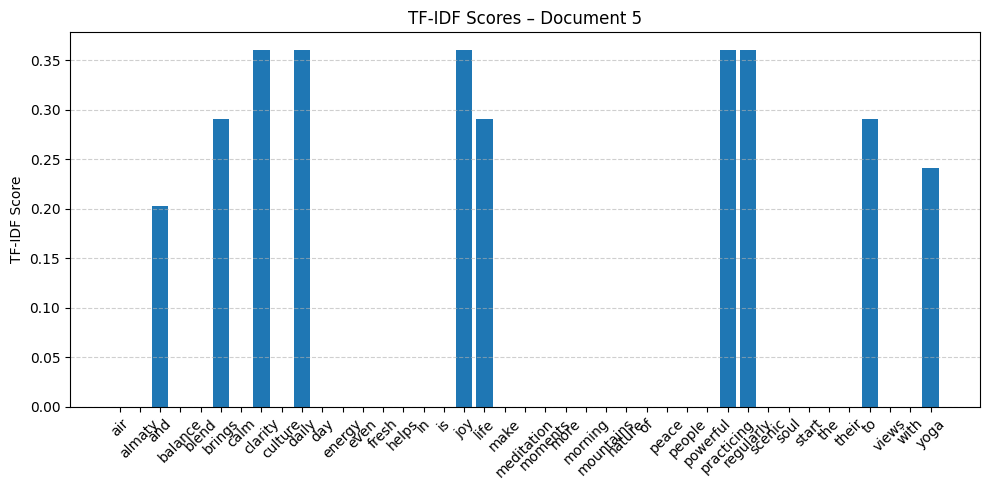

In [ ]:
# Visualize TF-IDF scores for each document
for i in range(len(corpus)):
    plt.figure(figsize=(10, 5))
    plt.bar(tfidf_df.columns, tfidf_df.iloc[i])
    plt.title(f"TF-IDF Scores – Document {i+1}")
    plt.ylabel("TF-IDF Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()


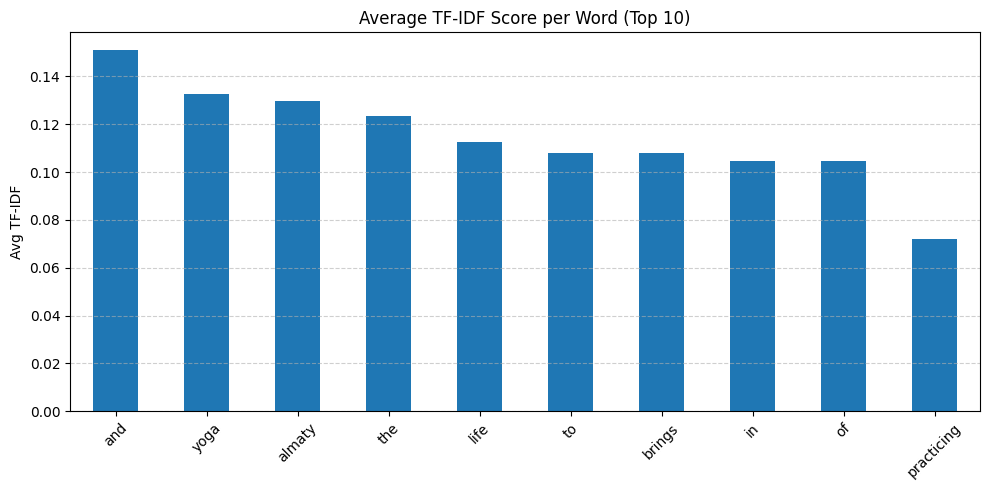

In [ ]:
# Calculate mean TF-IDF score across all documents
avg_tfidf = tfidf_df.mean().sort_values(ascending=False)

# Plot top 10 words by average TF-IDF score
plt.figure(figsize=(10, 5))
avg_tfidf[:10].plot(kind='bar')
plt.title("Average TF-IDF Score per Word (Top 10)")
plt.ylabel("Avg TF-IDF")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Exercise 2: Word2Vec (CBOW, Skip-gram)


In [ ]:
!pip install gensim matplotlib scikit-learn

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


In [ ]:
# Tokenized version of your corpus
sentences = [
    ["yoga", "in", "the", "mountains", "of", "almaty", "brings", "peace", "to", "the", "soul"],
    ["life", "in", "almaty", "is", "a", "blend", "of", "nature", "culture", "and", "calm", "moments"],
    ["morning", "yoga", "helps", "people", "start", "day", "with", "balance", "and", "energy"],
    ["almaty's", "fresh", "air", "and", "scenic", "views", "make", "meditation", "powerful"],
    ["practicing", "yoga", "regularly", "brings", "clarity", "and", "joy", "to", "daily", "life"]
]


In [ ]:
model_cbow = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=0)  # sg=0 = CBOW


In [ ]:
model_sg = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=1)  # sg=1 = Skip-gram


In [ ]:
# Check similarity between yoga and life
cbow_sim = model_cbow.wv.similarity('yoga', 'life')
sg_sim = model_sg.wv.similarity('yoga', 'life')

print(f"Cosine Similarity (CBOW) between 'yoga' and 'life': {cbow_sim:.3f}")
print(f"Cosine Similarity (Skip-gram) between 'yoga' and 'life': {sg_sim:.3f}")


Cosine Similarity (CBOW) between 'yoga' and 'life': 0.034
Cosine Similarity (Skip-gram) between 'yoga' and 'life': 0.034


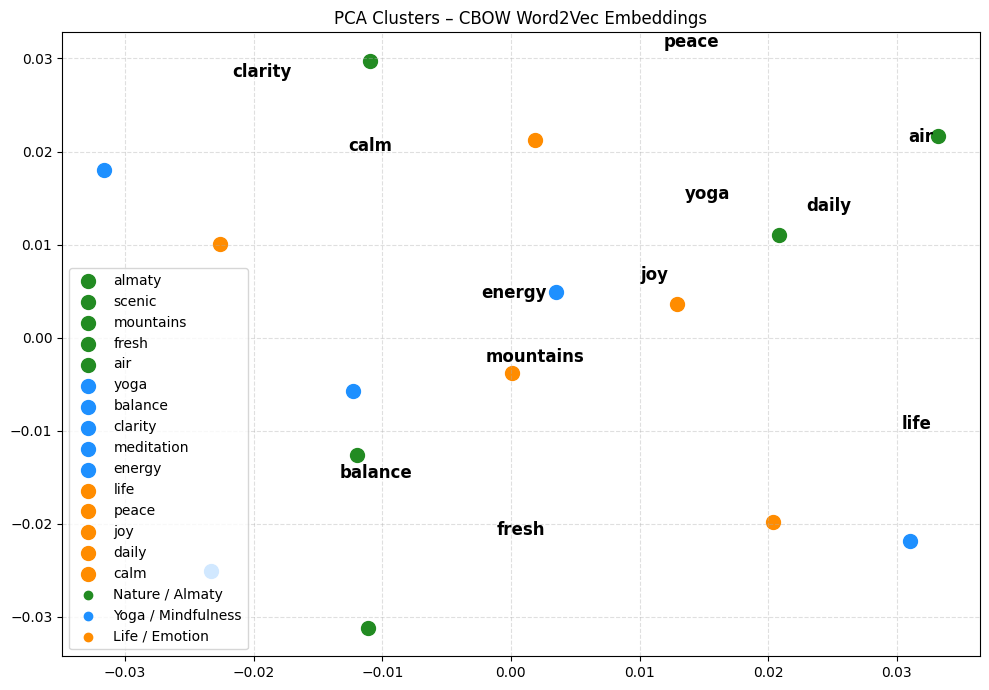

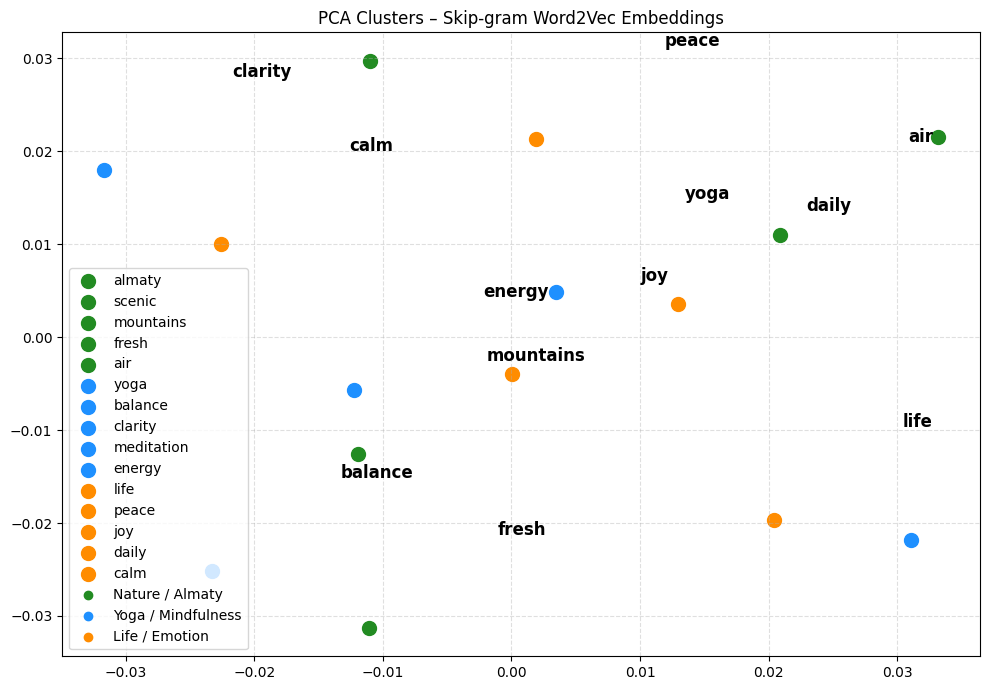

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Define semantic groups (clusters)
semantic_groups = {
    "Nature / Almaty": ['almaty', 'scenic', 'mountains', 'fresh', 'air'],
    "Yoga / Mindfulness": ['yoga', 'balance', 'clarity', 'meditation', 'energy'],
    "Life / Emotion": ['life', 'peace', 'joy', 'daily', 'calm']
}

def plot_clustered_words(model, title):
    word_vectors = []
    labels = []
    colors = []
    color_map = {
        "Nature / Almaty": 'forestgreen',
        "Yoga / Mindfulness": 'dodgerblue',
        "Life / Emotion": 'darkorange'
    }

    for group, words in semantic_groups.items():
        for word in words:
            if word in model.wv:
                word_vectors.append(model.wv[word])
                labels.append(word)
                colors.append(color_map[group])

    # Reduce to 2D
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(word_vectors)

    # Plot
    plt.figure(figsize=(10, 7))
    for i, label in enumerate(labels):
        plt.scatter(reduced[i, 0], reduced[i, 1], c=colors[i], s=100, label=label)
        plt.annotate(label, (reduced[i, 0]+0.01, reduced[i, 1]+0.01), fontsize=12, weight='bold')

    # Create legend from color map keys only once
    for group, color in color_map.items():
        plt.scatter([], [], c=color, label=group)

    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Run for both models
plot_clustered_words(model_cbow, "PCA Clusters – CBOW Word2Vec Embeddings")
plot_clustered_words(model_sg, "PCA Clusters – Skip-gram Word2Vec Embeddings")


Exercise 3: GloVe and FastText Embeddings


In [ ]:
!pip install gensim

from gensim.models import FastText, KeyedVectors
from gensim.downloader import load as api_load


In [ ]:
# Your thematic corpus
sentences = [
    ["yoga", "in", "the", "mountains", "of", "almaty", "brings", "peace", "to", "the", "soul"],
    ["life", "in", "almaty", "is", "a", "blend", "of", "nature", "culture", "and", "calm", "moments"],
    ["morning", "yoga", "helps", "people", "start", "day", "with", "balance", "and", "energy"],
    ["almaty's", "fresh", "air", "and", "scenic", "views", "make", "meditation", "powerful"],
    ["practicing", "yoga", "regularly", "brings", "clarity", "and", "joy", "to", "daily", "life"]
]


In [ ]:
# Load GloVe vectors (50-dimensional for faster load)
glove_model = api_load("glove-wiki-gigaword-50")  # Can also use 100 or 300


[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
# Find similar words (pretrained)
print("GloVe – Words similar to 'yoga':")
print(glove_model.most_similar("yoga", topn=5))

print("\nGloVe – Words similar to 'life':")
print(glove_model.most_similar("life", topn=5))


GloVe – Words similar to 'yoga':
[('meditation', 0.8521523475646973), ('hatha', 0.8089858889579773), ('pilates', 0.7537126541137695), ('aerobics', 0.7498380541801453), ('mindfulness', 0.7173849940299988)]

GloVe – Words similar to 'life':
[('mind', 0.8514840602874756), ('love', 0.8403437733650208), ('lives', 0.8392688632011414), ('own', 0.836990475654602), ('kind', 0.8338871598243713)]


In [ ]:
# Train FastText (you can use sg=1 for skip-gram)
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, sg=1)


In [ ]:
print("FastText – Words similar to 'yoga':")
print(fasttext_model.wv.most_similar("yoga", topn=5))

print("\nFastText – Words similar to 'life':")
print(fasttext_model.wv.most_similar("life", topn=5))


FastText – Words similar to 'yoga':
[('start', 0.27835214138031006), ('regularly', 0.2345411330461502), ('is', 0.13620762526988983), ('and', 0.1167847216129303), ('mountains', 0.11654981225728989)]

FastText – Words similar to 'life':
[('blend', 0.1902175396680832), ('joy', 0.1846025437116623), ('in', 0.13293983042240143), ('nature', 0.09739445149898529), ('and', 0.08341685682535172)]


**2. Recurrent Neural Networks (RNNs) for NLP**


Exercise 4: Understanding RNNs and the Vanishing Gradient Problem

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [ ]:

sequence_length = 10
num_sequences = 100

# Input: sequences of 0s with a 1 at the start
X = torch.zeros((num_sequences, sequence_length, 1))
y = torch.zeros((num_sequences, 1))

for i in range(num_sequences):
    X[i, 0, 0] = 1  # Set first element to 1
    y[i] = 1




In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # Use last hidden state
        return out


In [ ]:
model = SimpleRNN(input_size=1, hidden_size=10, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

gradient_magnitudes = []

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()

    # Capture average gradient magnitude from the first RNN weight
    grad = model.rnn.weight_hh_l0.grad
    gradient_magnitudes.append(grad.abs().mean().item())

    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 2.2633
Epoch 10, Loss: 0.0843
Epoch 20, Loss: 0.0818
Epoch 30, Loss: 0.0138
Epoch 40, Loss: 0.0021


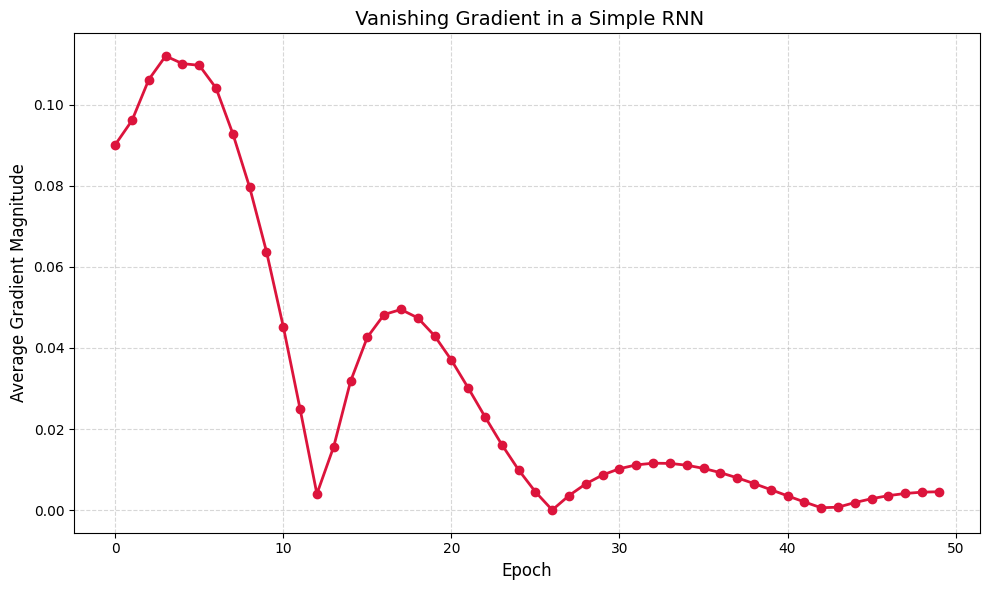

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(gradient_magnitudes, marker='o', linewidth=2, color='crimson')
plt.title(" Vanishing Gradient in a Simple RNN", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Average Gradient Magnitude", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Exercise 5: Applications in Text Classification and Sequence Modeling


In [ ]:
!pip install datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.


In [ ]:
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


In [ ]:
dataset = load_dataset("imdb")

train_data = dataset["train"].shuffle(seed=42).select(range(2000))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
tokenizer = get_tokenizer("basic_english")

def yield_tokens(data):
    for example in data:
        yield tokenizer(example["text"])

vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<pad>", "<unk>"])
vocab.set_default_index(vocab["<unk>"])


In [ ]:
def text_pipeline(text):
    return vocab(tokenizer(text))

def label_pipeline(label):
    return 1 if label == 1 else 0

def collate_batch(batch):
    text_list, label_list = [], []
    for example in batch:
        processed_text = torch.tensor(text_pipeline(example["text"]), dtype=torch.long)
        label = torch.tensor(label_pipeline(example["label"]), dtype=torch.float)
        text_list.append(processed_text)
        label_list.append(label)
    text_list = pad_sequence(text_list, batch_first=True, padding_value=vocab["<pad>"])
    label_list = torch.stack(label_list)
    return text_list, label_list

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_batch)


In [ ]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<pad>"])
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        return self.sigmoid(self.fc(hidden.squeeze(0)))


In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNClassifier(len(vocab), embed_dim=64, hidden_dim=32).to(device)

loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history, acc_history = [], []

for epoch in range(5):
    model.train()
    epoch_loss, correct, total = 0, 0, 0

    for texts, labels in train_dataloader:
        texts, labels = texts.to(device), labels.to(device)
        outputs = model(texts).squeeze()

        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    loss_history.append(epoch_loss)
    acc_history.append(acc)
    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {acc:.4f}")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

Epoch 1: Loss = 43.7838, Accuracy = 0.4980
Epoch 2: Loss = 43.6849, Accuracy = 0.4940
Epoch 3: Loss = 43.6808, Accuracy = 0.4870
Epoch 4: Loss = 43.6385, Accuracy = 0.4835
Epoch 5: Loss = 43.5615, Accuracy = 0.4995


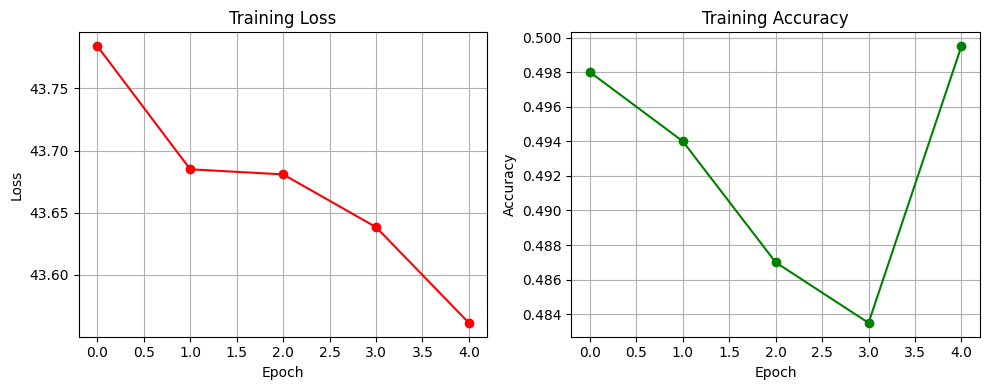

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', color='red')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(acc_history, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


3. Long Short-Term Memory (LSTM) and Gated Recurrent Units (GRU)


Exercise 6: LSTM vs. GRU – Key Differences


In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<pad>"])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        return self.sigmoid(self.fc(hidden.squeeze(0)))


In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<pad>"])
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        return self.sigmoid(self.fc(hidden.squeeze(0)))


In [ ]:
def train_model(model, dataloader, optimizer, loss_fn, device, epochs=5):
    model.to(device)
    loss_history, acc_history = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for texts, labels in dataloader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts).squeeze()

            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        loss_history.append(total_loss)
        acc_history.append(acc)
        print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Accuracy={acc:.4f}")

    return loss_history, acc_history


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = nn.BCELoss()

# LSTM
lstm_model = LSTMClassifier(len(vocab), embed_dim=64, hidden_dim=32)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
lstm_loss, lstm_acc = train_model(lstm_model, train_dataloader, lstm_optimizer, loss_fn, device)

# GRU
gru_model = GRUClassifier(len(vocab), embed_dim=64, hidden_dim=32)
gru_optimizer = optim.Adam(gru_model.parameters(), lr=0.001)
gru_loss, gru_acc = train_model(gru_model, train_dataloader, gru_optimizer, loss_fn, device)


Epoch 1: Loss=43.8034, Accuracy=0.5005
Epoch 2: Loss=43.6947, Accuracy=0.4885
Epoch 3: Loss=43.6285, Accuracy=0.5035
Epoch 4: Loss=43.5725, Accuracy=0.5025
Epoch 5: Loss=43.5416, Accuracy=0.5075
Epoch 1: Loss=43.6853, Accuracy=0.5030
Epoch 2: Loss=43.5980, Accuracy=0.4925
Epoch 3: Loss=43.5913, Accuracy=0.5070
Epoch 4: Loss=43.5581, Accuracy=0.4980
Epoch 5: Loss=43.4620, Accuracy=0.4980


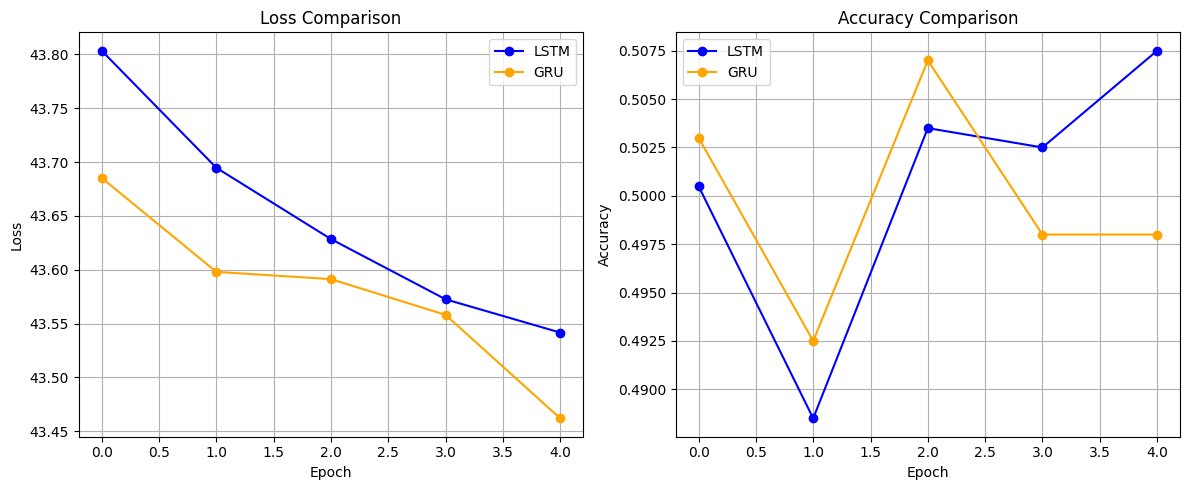

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_loss, label="LSTM", color="blue", marker='o')
plt.plot(gru_loss, label="GRU", color="orange", marker='o')
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_acc, label="LSTM", color="blue", marker='o')
plt.plot(gru_acc, label="GRU", color="orange", marker='o')
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Exercise 7: Implementing LSTMs for Text Generation and Classification

In [ ]:
abay_text = """
Was life good or bad, but it passed a lot. I had enough in this life: disputes, and painful gossip, and struggle and unworthy quarrels... But now, when I’m on the end of the road, being exhausted and tired, I am convinced of the futility of my good aspirations, in the vanity and frailty of human life. And tormented by the thought: What to devote the rest of my days? What to do? Try to alleviate the suffering of the people? Impossible. People are ungovernable. That’s the way for the one to whom the destiny prepared human ingratitude and curse, or youth, whose heart is hot and hasn’t still known the bitterness of defeat. Me, knowing this truth, save Allah from temptation.

Maybe increase the flock? Don't want to. Let the children if they ought to, bred cattle themselves. It would be a sin to waste the recent strength to alleviate the existence for thieves, beggars and villains.

Comprehend the science? It is impossible. I have no one to give the knowledge, and from whom to take them. What's the use to sit in the desert, spreading expensive cloth and holding a yard? When there’s no one to share the grief or joy, the science turns into a burden: faster ages.

Or, maybe devote myself to God? It goes wrong. The peace is required to believe. Whence to take godliness when there’s no calm neither in my feelings, nor in daily life? This world does not tolerate pilgrims.

To bring up children? I can’t. Maybe I would, if I knew how and what to teach them, and whether the people that I see today need it at all. I cannot imagine the future of children worthy the use of their education and forces, and therefore cannot see the way of upbringing.

Finally I decided to take companions, paper and ink, and to write down all my thoughts.

Maybe someone will like any of my word, and he will rewrite it for himself, or just remember; and if not my words, as they say, will stay with me. At this point I stopped, and I have no other occupation than writing.
In my childhood I heard a lot about how the Kazakhs seeing the Uzbeks laughed at them: «Oh, you wide-brimmed, with an unclear jabber instead of human speech. You wouldn’t leave on the road, even a bundle of rotten reed! You take the bush at night for the enemy, fawn in the eyes, and revile people behind the eyes. That’s why we call you «SART» which means a loud knocking or crackle».

The Kazakhs also laughed over the Nogais- the Tatars. «Hey, Tatars, you're afraid of camel, while riding on a horse get tired; you rest, when you are walking. You have a bearish agility, and your name is not Nogais but Nokais- clumsy. Maybe that’s why, all we just see around: the soldier – the Tatar, the fugitive – the Tatar, the grocer – the Tartar».

They also laughed over the Russians. «Redheads do everything that comes to their mind. Seeing yurts in the endless steppe rush headlong to them and believe everything they are told. We even asked them to show the "Uzun-fist", and try to see yourself how they found out about you at the other end of the steppe ...»

I laughed joyfully and proudly, listening to these stories. «Oh, Allah, - I thought delighted – no one, it turns out, cannot compare with my great nation. » Now I see that there is no plant that is not raised by the Sart, no tastier fruit than in the garden of the Sart. You will not find a country that is not visited by the Sart, trading, there is simply no thing that he could not make. Everyone in the town is too busy to keep an eye on each other’s affairs, that’s why they are more amicable. Earlier in fact they made ​​clothes for the Kazakhs. We took even shrouds for the dead from them, instead we gave them cattle, for which foolishly killed each other. When the Russians came, the Sarts were ahead of us again, having adopted from the Russians their skills. Wealth, and piety, and skills, and courtesy- all of these have the Sarts now.

Look at the Tatars. They carry soldiery, withstand poverty, endure grief and love God.

The Tatars are able to work hard, know how to amass wealth and how to live in luxury.

Even the most elected of our rich they kick out of the house: "Our floor glitters not for your footprints, Kazakh, left on it with your muddy boots!"

There is nothing to say about the Russians. We cannot be compared even with their servants.

Where did our boasting, pride for the family, and a sense of superiority over our neighbors disappear? Where is my happy laughter?

 Why do the Kazakhs look at each other like wolves? Why do not they have empathy to relatives, why is there no truth? When and where from did idleness and laziness come into the blood of the proud steppe peoples? Great sages have noticed long ago: each idler is weak-willed and cowardly; a weak-willed man is always boastful; a boastful man except cowardice is also a fool; and the fool is always ignorant and dishonest. Out of dishonest come the greedy, quarrelsome and talentless creatures, useless in the world.

That's happened to us. And the reason for this is the removal of agriculture, commerce, crafts and science. We only think how to increase our flocks and herds, provide cattle not only for us, but also for our children. When it succeeds, the herds are passed to the shepherds, and we, newly appeared rich people only eat meat to satiety, drink our heady kumyz, have fun with beauties, and enjoy running horses. If winter yurts are getting crowded, we start to trade or struggle with neighbors, making slander, bribery, blood feuds. The victim also oppresses another neighbor.

And one day, a black song idea was born: let the people get poorer more and more, because the poorer people, the cheaper their work, the roomier pastures and the more defenseless their winter yurts. We dream about the impoverishment of the contenders, they want to bankrupt us. So, tell me, is it possible to wish good to each other?

  We began to feud, fight; we divided into groups and in order to defend our wealth and pastures, started bickering for the power. No one was left out of this vortex. People did not leave their homelands to learn an unfamiliar craft, did not cultivated fields, and did not seek to benefit from the trade. They traded only themselves, adhering to one or to the other party.

  Thieves did not disappear- they were needed for quarrels. But the best people were slandered, criminal proceedings were initiated against them, false witnesses were selected. And all this was done in order to block the path to the power for the honest. Slandered and humiliated, some of them turned for help to the powers that be, and then the steppe lost another honest son. There remained one way to more proud one - while away his days in prison.

Rural municipality governors achieved their position by guile and cunning, and supported the unjust, because it’s better to make friends than feud with similar. Cunning is limitless –impossible to determine who will deceive tomorrow.

There is the truth in what the proverb says: «Never judge a man by his actions, but judge by his intentions». It turns out that people have believed that nothing can be achieved by the honest work, but they can get everything through deception.
Where is the root cause of this trouble?

Rural municipality is selected for three years. The first year flies in the little offenses of the people who elected him, in mutual reproaches and flirting. The second year goes in the fight of the governor with the candidate on his place: to try to win even on the distant approaches to elections. The third year continues in giving promises because everyone hopes to remain in place of the governor for the next period. I see how in this turmoil my people are getting shallow every year and become more immoral.

It’s hard to look at them. Why, for example, not to elect a rural municipality out of the people who were educated in Russian? If not, then let the rural municipality be appointed by a county chief or even by the military governor. There will be less work.

It would be also good not to elect but appoint the judges for them not to look back at every step on steppe tycoons. There would be less slander.

Biys - steppe judges - have already made harm because they have completely lost the good grandfather's traditions. Not every Biy remembers now «old truths», bequeathed by the ESIM-Khan, or «shining path», drawn by Kasym-Khan, or «seven bodies of law» left by the wise Tauke. But they still have to know that their outdated laws and regulations do not respond the spirit of time, prevent new life. Where can we find the wise Biys? There are almost none.

  Our grandfathers used to say: "Where there are two Biys, four disputes are being born." The meaning of these words is that an even number of Biys will never come to a consensus. I think it would be better to elect three Biys on every rural district, to elect the most worthy and on the constant term. Then the replacement of any of them will be an event and a reminder of the justice for the others. But Biys should not immediately decide litigation themselves. My mind is. Quarreling parties choose one defender, they are joined by a mediator, and these three lead a particular case. If the case will not be solved, one of Biys, which, for example, can be selected by lot, comes to help them. Wouldn’t this be the way to solve many disputes of our lives?
"""

# Convert characters to lowercase and build vocab
text = abay_text.lower()
chars = sorted(set(text))
char_to_idx = {char: i for i, char in enumerate(chars)}
idx_to_char = {i: char for char, i in char_to_idx.items()}
vocab_size = len(chars)

# Encode entire text
encoded_text = [char_to_idx[c] for c in text]

In [ ]:
seq_length = 40
step = 1

input_seqs = []
target_seqs = []

for i in range(0, len(encoded_text) - seq_length, step):
    input_seqs.append(encoded_text[i: i + seq_length])
    target_seqs.append(encoded_text[i + 1: i + seq_length + 1])

# Convert to tensors
X = torch.tensor(input_seqs, dtype=torch.long)
Y = torch.tensor(target_seqs, dtype=torch.long)


In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden


In [ ]:
model = CharLSTM(vocab_size)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

n_epochs = 50

batch_size = 4

for epoch in range(n_epochs):
    model.train()
    total_loss = 0

    for i in range(0, len(X), batch_size):
        x_batch = X[i:i+batch_size]
        y_batch = Y[i:i+batch_size]

        optimizer.zero_grad()
        output, _ = model(x_batch)
        loss = loss_fn(output.view(-1, vocab_size), y_batch.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 4623.1287
Epoch 2, Loss: 5152.5604
Epoch 3, Loss: 5335.1639
Epoch 4, Loss: 5266.6340
Epoch 5, Loss: 5323.4420
Epoch 6, Loss: 5293.8077
Epoch 7, Loss: 5353.3475
Epoch 8, Loss: 5408.4561
Epoch 9, Loss: 5452.1022
Epoch 10, Loss: 5490.5036
Epoch 11, Loss: 5474.5745
Epoch 12, Loss: 5381.5683
Epoch 13, Loss: 5446.8387
Epoch 14, Loss: 5410.3535
Epoch 15, Loss: 5500.4466
Epoch 16, Loss: 5453.2791
Epoch 17, Loss: 5405.8615
Epoch 18, Loss: 5455.0742
Epoch 19, Loss: 5542.5256
Epoch 20, Loss: 5419.6071
Epoch 21, Loss: 5410.5072
Epoch 22, Loss: 5429.0772
Epoch 23, Loss: 5502.5590
Epoch 24, Loss: 5514.1674
Epoch 25, Loss: 5495.5465
Epoch 26, Loss: 5567.9753
Epoch 27, Loss: 5543.1882
Epoch 28, Loss: 5516.8697
Epoch 29, Loss: 5472.7572
Epoch 30, Loss: 5454.1269
Epoch 31, Loss: 5432.9568
Epoch 32, Loss: 5487.2364
Epoch 33, Loss: 5488.9440
Epoch 34, Loss: 5564.4534
Epoch 35, Loss: 5586.8231
Epoch 36, Loss: 5579.6850
Epoch 37, Loss: 5596.6212
Epoch 38, Loss: 5462.0795
Epoch 39, Loss: 5485.

In [ ]:
import torch.nn.functional as F

def generate_text(model, start_str, gen_length=300, temperature=1.0):
    model.eval()
    input_seq = torch.tensor([char_to_idx[c] for c in start_str.lower()], dtype=torch.long).unsqueeze(0)
    hidden = None
    generated = start_str

    with torch.no_grad():
        for _ in range(gen_length):
            output, hidden = model(input_seq, hidden)
            last_logits = output[:, -1, :] / temperature
            probs = F.softmax(last_logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1).item()
            next_char = idx_to_char[next_idx]
            generated += next_char
            input_seq = torch.tensor([[next_idx]])

    return generated


In [ ]:
print(generate_text(model, "O gentle"))


O gentlelol to olve thys beo’t, wicipaly fotpeald beist, fotp chito mefed secas footp woosplote bed les, nos, comeles totot, be be wild coote. of by chiy tpor, coms notwos. wos lon se be of by themoullven mplel, tow se bednnd, be hos paftds. loool. bick walhs wintemelveseled by for themecosplalis, sthiys th


Exercise 8: Improving Performance with Bidirectional LSTMs

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<pad>"])
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # 2x hidden_dim because it's bidirectional
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.bilstm(embedded)
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)  # forward and backward hidden states
        return self.sigmoid(self.fc(hidden))


In [ ]:
bilstm_model = BiLSTMClassifier(len(vocab), embed_dim=64, hidden_dim=32)
bilstm_optimizer = optim.Adam(bilstm_model.parameters(), lr=0.001)

bilstm_loss, bilstm_acc = train_model(bilstm_model, train_dataloader, bilstm_optimizer, loss_fn, device)


Epoch 1: Loss=3457.6780, Accuracy=0.5030
Epoch 2: Loss=3456.6194, Accuracy=0.5615
Epoch 3: Loss=3441.9721, Accuracy=0.6040
Epoch 4: Loss=3417.2300, Accuracy=0.6425
Epoch 5: Loss=3368.1022, Accuracy=0.7090


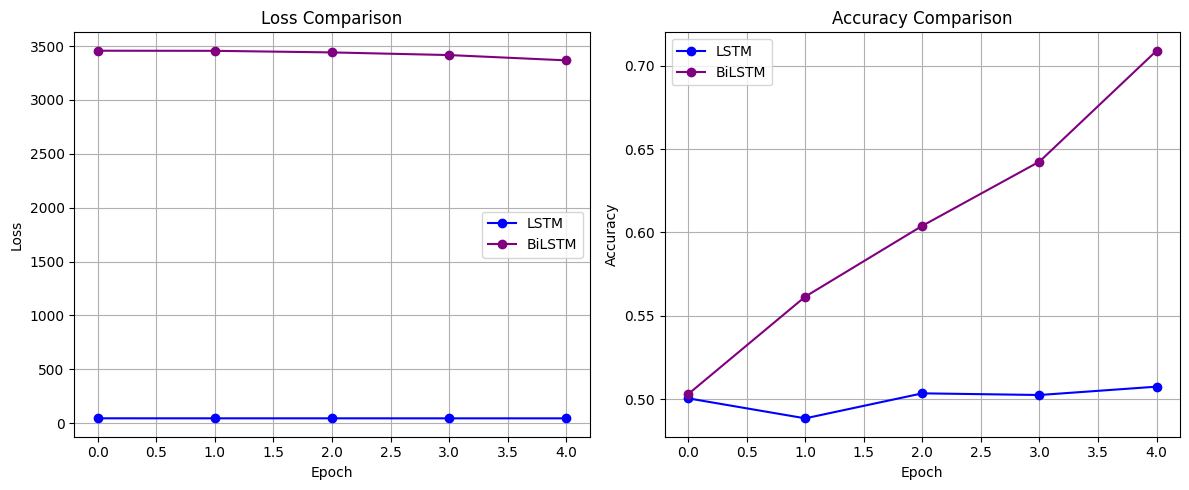

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_loss, label="LSTM", color="blue", marker='o')
plt.plot(bilstm_loss, label="BiLSTM", color="purple", marker='o')
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_acc, label="LSTM", color="blue", marker='o')
plt.plot(bilstm_acc, label="BiLSTM", color="purple", marker='o')
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
